In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
print(df.head())


      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


In [2]:
print("Shape of Dataset:", df.shape)
print("\nColumns:")
print(df.columns)

Shape of Dataset: (5110, 12)

Columns:
Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')


In [3]:
age_groups = pd.cut(
    df["age"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["0-20", "21-40", "41-60", "61-80", "81-100"]
)

avg_glucose = df.groupby(
    age_groups,
    observed=False
)["avg_glucose_level"].mean()

print(avg_glucose)

age
0-20       94.345210
21-40      96.773380
41-60     107.936665
61-80     121.893165
81-100    123.602500
Name: avg_glucose_level, dtype: float64


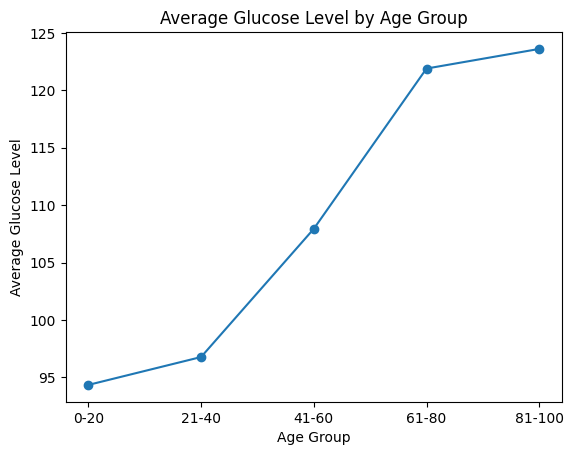

In [4]:
plt.plot(avg_glucose.index, avg_glucose.values, marker='o')

plt.title("Average Glucose Level by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Glucose Level")

plt.show()

In [5]:
stroke_gender = df[df["stroke"] == 1]["gender"].value_counts()

print(stroke_gender)

gender
Female    141
Male      108
Name: count, dtype: int64


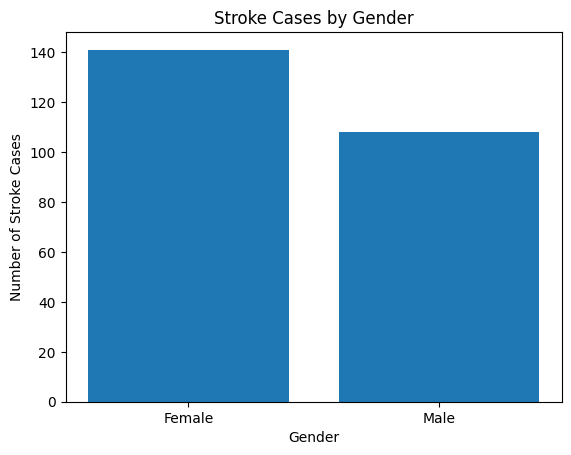

In [6]:
plt.bar(stroke_gender.index, stroke_gender.values)

plt.title("Stroke Cases by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Stroke Cases")

plt.show()

In [7]:
stroke_counts = df["stroke"].value_counts()

print(stroke_counts)

stroke
0    4861
1     249
Name: count, dtype: int64


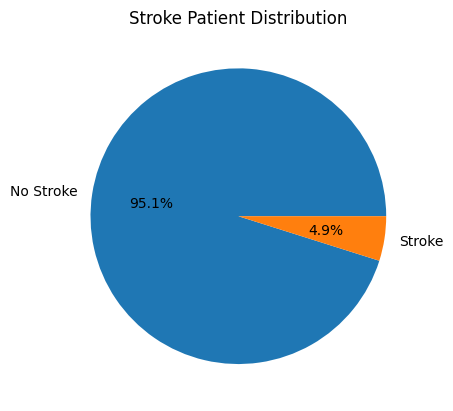

In [8]:
labels = ["No Stroke", "Stroke"]

plt.pie(
    stroke_counts,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Stroke Patient Distribution")
plt.show()

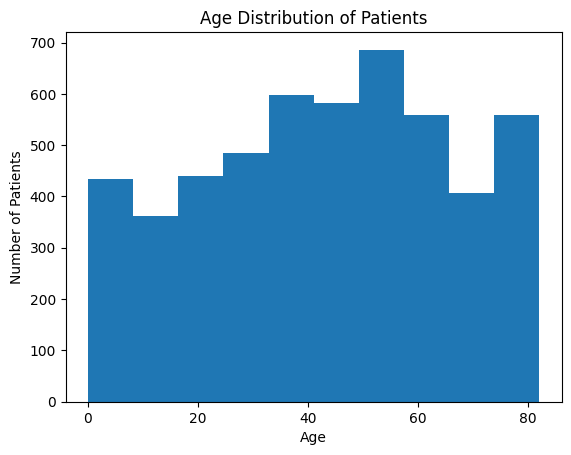

In [9]:
plt.hist(df["age"], bins=10)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

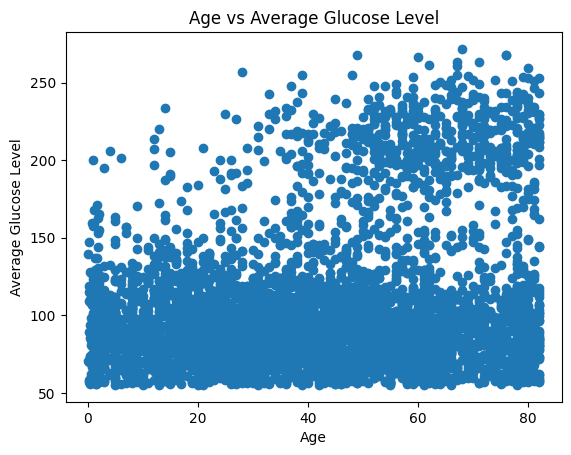

In [10]:
plt.scatter(df["age"], df["avg_glucose_level"])

plt.title("Age vs Average Glucose Level")
plt.xlabel("Age")
plt.ylabel("Average Glucose Level")

plt.show()

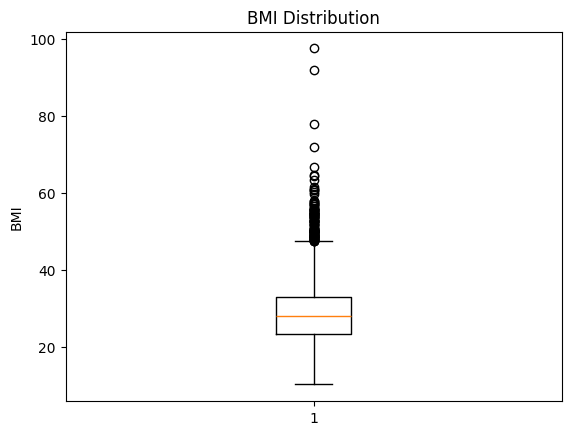

In [11]:
bmi_data = df["bmi"].dropna()

plt.boxplot(bmi_data)

plt.title("BMI Distribution")
plt.ylabel("BMI")

plt.show()

In [12]:
stroke_age = df[df["stroke"] == 1]

stroke_age_groups = pd.cut(
    stroke_age["age"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["0-20", "21-40", "41-60", "61-80", "81-100"]
)

stroke_age_counts = stroke_age_groups.value_counts().sort_index()

print(stroke_age_counts)

age
0-20        2
21-40       6
41-60      64
61-80     154
81-100     23
Name: count, dtype: int64


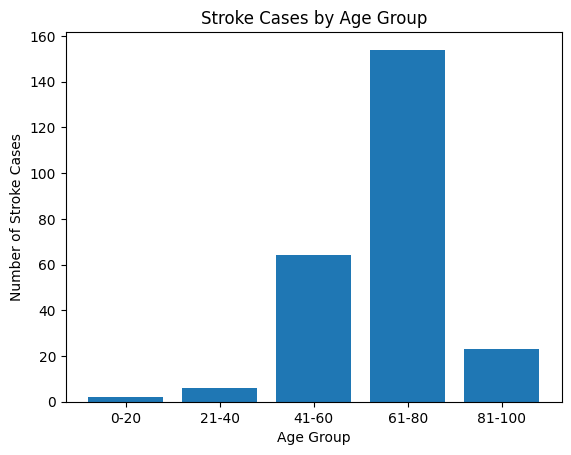

In [13]:
plt.bar(stroke_age_counts.index, stroke_age_counts.values)

plt.title("Stroke Cases by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Stroke Cases")

plt.show()